# P6 – Detección de Objetos | MyCobot 280
**Cinemática, Control y Visión de Robots – ROB 2026**

Detecta el cubo **amarillo** con OpenCV.  
Convierte centroide en píxeles → mm en el sistema del robot.  
Usa la API `pymycobot`:
- `mc.send_angles()` → mover a **watch_pose** antes de detectar  
- `mc.get_coords()` → leer posición real del robot para validar

---
`Puerto: /dev/ttyUSB0` | `Baud: 1_000_000` | `Robot: Yahboom MyCobot 280`

## 0. Liberar cámara ⚠️ EJECUTAR SIEMPRE PRIMERO

Mata cualquier proceso que tenga ocupada `/dev/video0` y destruye ventanas OpenCV colgadas.
Corre esta celda **antes de cualquier otra** cada vez que abras el notebook.

In [1]:
import subprocess, time, gc
try:
    import cv2
except ImportError:
    pass

# 1. Cerrar instancia cap previa si existe
try:
    cap.release()
    print('Instancia cap anterior liberada.')
except NameError:
    print('No habia cap abierta.')

# 2. Destruir ventanas OpenCV
try:
    cv2.destroyAllWindows()
except Exception:
    pass

# 3. Matar procesos que bloqueen la camara
r = subprocess.run(
    'fuser /dev/video0 /dev/video1 2>/dev/null',
    shell=True, capture_output=True, text=True
)
pids = r.stdout.strip().split()
if pids:
    for pid in pids:
        subprocess.run(f'kill -9 {pid}', shell=True)
    print(f'Procesos eliminados: {pids}')
    time.sleep(1.5)
else:
    print('Camara libre, ningun proceso bloqueandola.')

gc.collect()
print('Listo para continuar.')

No habia cap abierta.
Camara libre, ningun proceso bloqueandola.
Listo para continuar.


## 1. Importaciones

In [2]:
import cv2
import numpy as np
import time
import gc
import subprocess
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# API del robot
try:
    from pymycobot.mycobot import MyCobot
    mc = MyCobot('/dev/ttyUSB0', 1_000_000)
    mc.power_on()
    time.sleep(0.5)
    assert mc.is_controller_connected(), 'Robot no conectado'
    ROBOT_DISPONIBLE = True
    print('Robot conectado')
except Exception as e:
    print(f'Robot no disponible ({e}). Modo solo-vision.')
    mc = None
    ROBOT_DISPONIBLE = False

print(f'  OpenCV : {cv2.__version__}')
print(f'  NumPy  : {np.__version__}')

Robot no disponible (No module named 'pymycobot'). Modo solo-vision.
  OpenCV : 4.13.0
  NumPy  : 2.0.2


## 2. Parámetros de calibración cámara ↔ robot

In [3]:
# ── RESOLUCIÓN ────────────────────────────────────────────────────────
IMG_WIDTH  = 640
IMG_HEIGHT = 480

# ── ÍNDICE DE CÁMARA ──────────────────────────────────────────────────
CAM_INDEX = 0  # cambiar a 1 si /dev/video0 no es la correcta

# ── ORIGEN: posición del robot cuando el cubo está en el centro óptico
# Cómo calibrar: pon el cubo en el centro de la imagen y lee mc.get_coords()
CAM_ORIGIN_X_MM = 150.0   # <-- ajustar en laboratorio
CAM_ORIGIN_Y_MM =   0.0   # <-- ajustar en laboratorio

# ── ESCALA: mm por píxel ───────────────────────────────────────────────
# Cómo calibrar: mide cuántos píxeles ocupa algo de ancho conocido (ej 50 mm)
# SCALE = ancho_real_mm / ancho_px
SCALE_X_MM_PX = 0.50      # <-- calibrar
SCALE_Y_MM_PX = 0.50      # <-- calibrar

# ── POSES DEL ROBOT (de tu calibración P5) ────────────────────────────
WATCH_POSE   = [1.14,   -0.96,  -1.31,  -2.1,   0.61,  -44.29]
PICK_UPPER   = [116.71, -18.19, -73.21,  3.69,   0.61,  -17.57]
PICK_GRASP   = [122.25, -37.79, -83.32, 30.67,  -5.18,  -11.33]
PLACE_UPPER  = [-84.46, -28.74, -63.54,  2.98,   1.14,  -38.75]
PLACE_GRASP  = [-86.48, -32.87, -92.54, 39.99,   0.43,  -41.48]
WATCH_SPEED  = 30

# ── FILTROS DE CONTORNO ───────────────────────────────────────────────
MIN_CONTOUR_AREA =    500
MAX_CONTOUR_AREA = 150_000

print('Parametros cargados:')
print(f'  Resolucion   : {IMG_WIDTH}x{IMG_HEIGHT}')
print(f'  WATCH_POSE   : {WATCH_POSE}')
print(f'  Escala       : {SCALE_X_MM_PX} mm/px')

Parametros cargados:
  Resolucion   : 640x480
  WATCH_POSE   : [1.14, -0.96, -1.31, -2.1, 0.61, -44.29]
  Escala       : 0.5 mm/px


## 3. Rangos HSV por color

| Color    | H min | H max | S min | V min | Nota |
|----------|-------|-------|-------|-------|------|
| Amarillo | 15    | 38    | 80    | 100   | Cubo principal |
| Azul     | 95    | 125   | 60    | 20    | Fondo tablero |
| Verde    | 38    | 85    | 60    | 40    | — |
| Rojo     | 0–12  | +168–180 | 100 | 60  | Dos rangos (cruza 0/180) |

> Calibrar con la **Sección 5** usando la iluminación real del laboratorio.

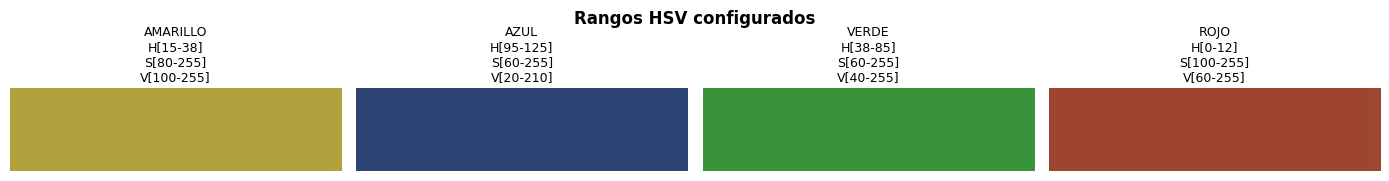

HSV_RANGES definido para 4 colores


In [4]:
HSV_RANGES = {
    'amarillo': {
        'lower'      : np.array([ 15,  80, 100]),
        'upper'      : np.array([ 38, 255, 255]),
        'color_bgr'  : (  0, 220, 220),
        'color_label': 'AMARILLO',
    },
    'azul': {
        'lower'      : np.array([ 95,  60,  20]),
        'upper'      : np.array([125, 255, 210]),
        'color_bgr'  : (255,   0,   0),
        'color_label': 'AZUL',
    },
    'verde': {
        'lower'      : np.array([ 38,  60,  40]),
        'upper'      : np.array([ 85, 255, 255]),
        'color_bgr'  : (  0, 200,   0),
        'color_label': 'VERDE',
    },
    'rojo': {
        'lower'      : np.array([  0, 100,  60]),
        'upper'      : np.array([ 12, 255, 255]),
        'lower2'     : np.array([168, 100,  60]),
        'upper2'     : np.array([180, 255, 255]),
        'color_bgr'  : (  0,   0, 220),
        'color_label': 'ROJO',
    },
}

# Visualizar swatches de color
fig, axes = plt.subplots(1, 4, figsize=(14, 2))
for ax, (nombre, cfg) in zip(axes, HSV_RANGES.items()):
    mid_h = int((cfg['lower'][0] + cfg['upper'][0]) / 2)
    mid_s = int((cfg['lower'][1] + cfg['upper'][1]) / 2)
    mid_v = int((cfg['lower'][2] + cfg['upper'][2]) / 2)
    swatch = np.zeros((50, 200, 3), dtype=np.uint8)
    swatch[:] = [mid_h, mid_s, mid_v]
    rgb = cv2.cvtColor(swatch, cv2.COLOR_HSV2RGB)
    ax.imshow(rgb)
    ax.set_title(
        f"{nombre.upper()}\nH[{cfg['lower'][0]}-{cfg['upper'][0]}]\n"
        f"S[{cfg['lower'][1]}-{cfg['upper'][1]}]\n"
        f"V[{cfg['lower'][2]}-{cfg['upper'][2]}]", fontsize=9)
    ax.axis('off')
plt.suptitle('Rangos HSV configurados', fontweight='bold')
plt.tight_layout()
plt.show()
print('HSV_RANGES definido para 4 colores')

## 4. Funciones utilitarias

### 4a. Abrir y liberar cámara

In [5]:
def abrir_camara(camera_index=0):
    """
    Abre camara en Jetson via GStreamer (YUY2).
    Espera hasta recibir frames reales (max 4 seg).
    Fallback a V4L2 si GStreamer falla.
    """
    pipeline = (
        f'v4l2src device=/dev/video{camera_index} ! '
        'video/x-raw,format=YUY2,width=640,height=480,framerate=30/1 ! '
        'videoconvert ! video/x-raw,format=BGR ! '
        'appsink drop=true sync=false max-buffers=1'
    )
    cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

    if not cap.isOpened():
        print('GStreamer fallo, probando V4L2...')
        cap = cv2.VideoCapture(f'/dev/video{camera_index}', cv2.CAP_V4L2)
        if not cap.isOpened():
            print('No se pudo abrir la camara.')
            return None

    print(f'Esperando frames de /dev/video{camera_index}...', end='')
    for i in range(40):
        ret, frame = cap.read()
        if ret and frame is not None and frame.size > 0:
            print(f' OK ({i+1} intentos)')
            return cap
        time.sleep(0.1)

    print(' timeout.')
    cap.release()
    return None


def liberar_camara(cap_obj=None):
    """
    Libera el objeto cap dado y mata procesos que bloqueen /dev/video0.
    Si no se pasa cap_obj, solo mata los procesos del sistema.
    """
    if cap_obj is not None:
        cap_obj.release()
    try:
        cv2.destroyAllWindows()
    except Exception:
        pass
    r = subprocess.run(
        'fuser /dev/video0 /dev/video1 2>/dev/null',
        shell=True, capture_output=True, text=True
    )
    pids = r.stdout.strip().split()
    if pids:
        for pid in pids:
            subprocess.run(f'kill -9 {pid}', shell=True)
        print(f'Procesos eliminados: {pids}')
        time.sleep(1)
    else:
        print('Camara libre.')
    gc.collect()


print('abrir_camara() y liberar_camara() definidas OK')

abrir_camara() y liberar_camara() definidas OK


### 4b. Transformación píxel → mm

In [6]:
def pixel_to_mm(cx_px, cy_px):
    """
    Convierte centroide (cx, cy) en pixeles a coordenadas (x, y) en mm
    en el sistema de referencia del robot.
    El eje Y de la imagen va hacia abajo; el del robot hacia arriba -> se invierte.
    """
    dx_px = cx_px - IMG_WIDTH  / 2.0
    dy_px = cy_px - IMG_HEIGHT / 2.0
    x_mm  = CAM_ORIGIN_X_MM + dx_px * SCALE_X_MM_PX
    y_mm  = CAM_ORIGIN_Y_MM - dy_px * SCALE_Y_MM_PX
    return round(x_mm, 1), round(y_mm, 1)


# Verificacion rapida
casos = [(0,0), (320,240), (640,480), (80,180), (420,150)]
print(f"{'Pixeles (cx,cy)':>22} | {'X robot (mm)':>14} | {'Y robot (mm)':>14}")
print('-'*55)
for cx, cy in casos:
    xm, ym = pixel_to_mm(cx, cy)
    print(f'  ({cx:>3}, {cy:>3})            | {xm:>14.1f} | {ym:>14.1f}')

print('pixel_to_mm() OK')

       Pixeles (cx,cy) |   X robot (mm) |   Y robot (mm)
-------------------------------------------------------
  (  0,   0)            |          -10.0 |          120.0
  (320, 240)            |          150.0 |            0.0
  (640, 480)            |          310.0 |         -120.0
  ( 80, 180)            |           30.0 |           30.0
  (420, 150)            |          200.0 |           45.0
pixel_to_mm() OK


### 4c. Detección principal

In [7]:
def detect_object(frame, target_color='amarillo', debug=False):
    """
    Detecta el cubo del color indicado en el frame BGR.

    Parametros
    ----------
    frame        : imagen BGR de OpenCV
    target_color : 'amarillo' | 'azul' | 'verde' | 'rojo'
    debug        : si True, dibuja anotaciones sobre el frame

    Retorna
    -------
    dict {color, cx_px, cy_px, x_mm, y_mm, area}  o  None
    """
    if target_color not in HSV_RANGES:
        raise ValueError(f"Color '{target_color}' no definido. "
                         f"Opciones: {list(HSV_RANGES.keys())}")

    cfg = HSV_RANGES[target_color]

    # 1. Normalizar brillo con CLAHE (maneja iluminacion variable)
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    frame_eq = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

    # 2. Suavizar y convertir a HSV
    blur = cv2.GaussianBlur(frame_eq, (7, 7), 0)
    hsv  = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)

    # 3. Mascara de color
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    if 'lower2' in cfg:  # rojo cruza H=0/180
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, cfg['lower2'], cfg['upper2']))

    # 4. Morfologia: quitar ruido (OPEN) y rellenar huecos (CLOSE)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 5. Contornos externos
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours
             if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]
    if not valid:
        return None

    # 6. Elegir el contorno mas grande
    best = max(valid, key=cv2.contourArea)
    area = cv2.contourArea(best)

    # 7. Centroide con momentos
    M = cv2.moments(best)
    if M['m00'] == 0:
        return None
    cx = M['m10'] / M['m00']
    cy = M['m01'] / M['m00']
    x_mm, y_mm = pixel_to_mm(cx, cy)

    result = {
        'color' : target_color,
        'cx_px' : round(cx, 1),
        'cy_px' : round(cy, 1),
        'x_mm'  : x_mm,
        'y_mm'  : y_mm,
        'area'  : int(area),
    }

    if debug:
        col   = cfg['color_bgr']
        cx_i, cy_i = int(cx), int(cy)
        bx, by, bw, bh = cv2.boundingRect(best)
        cv2.rectangle(frame, (bx, by), (bx+bw, by+bh), col, 2)
        cv2.circle(frame, (cx_i, cy_i), 7, col, -1)
        cv2.putText(frame,
                    f"{cfg['color_label']}  ({x_mm},{y_mm}) mm",
                    (cx_i + 10, cy_i - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return result


def detect_all(frame, debug=False):
    """Detecta los 4 colores en el mismo frame."""
    return {color: detect_object(frame, color, debug=debug)
            for color in HSV_RANGES}


def detectar_color_automatico(frame, debug=False):
    """Prueba los 4 colores y devuelve el de contorno mas grande."""
    mejor, mayor_area = None, 0
    for color in HSV_RANGES:
        res = detect_object(frame, color)
        if res and res['area'] > mayor_area:
            mayor_area = res['area']
            mejor = res
    if mejor and debug:
        detect_object(frame, mejor['color'], debug=True)
    return mejor


print('detect_object(), detect_all(), detectar_color_automatico() OK')

detect_object(), detect_all(), detectar_color_automatico() OK


### 4d. Detección robusta (P6.5)

In [8]:
def detect_robust(frame, target_color='amarillo', min_confidence=0.6):
    """
    Version robusta con manejo de:
    - Objeto ausente
    - Falsos positivos (multiples contornos)
    - Iluminacion variable (CLAHE incluido en detect_object)

    Retorna (result_dict | None, confidence_score, warning_msg)
    """
    cfg = HSV_RANGES[target_color]

    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    frame_eq = cv2.cvtColor(cv2.merge([l, a, b_ch]), cv2.COLOR_LAB2BGR)

    blur = cv2.GaussianBlur(frame_eq, (7,7), 0)
    hsv  = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    if 'lower2' in cfg:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, cfg['lower2'], cfg['upper2']))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours
             if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

    if not valid:
        return None, 0.0, 'OBJETO AUSENTE'

    warning = ''
    if len(valid) > 1:
        areas = [cv2.contourArea(c) for c in valid]
        ratio = max(areas) / sum(areas)
        if ratio < 0.7:
            warning = (f'ALERTA: {len(valid)} contornos detectados '
                       f'({[int(a) for a in areas]} px2) — posible falso positivo')

    best = max(valid, key=cv2.contourArea)
    area = cv2.contourArea(best)

    perimeter  = cv2.arcLength(best, True)
    confidence = min(1.0, (4*np.pi*area / (perimeter**2 + 1e-6)) / 0.85)

    if confidence < min_confidence:
        warning += f' | Baja confianza: {confidence:.2f}'

    M = cv2.moments(best)
    if M['m00'] == 0:
        return None, 0.0, 'ERROR: momento nulo'

    cx, cy = M['m10']/M['m00'], M['m01']/M['m00']
    x_mm, y_mm = pixel_to_mm(cx, cy)

    result = dict(color=target_color,
                  cx_px=round(cx,1), cy_px=round(cy,1),
                  x_mm=x_mm, y_mm=y_mm, area=int(area))
    return result, round(confidence, 3), warning


print('detect_robust() OK')

detect_robust() OK


## 5. Calibración HSV interactiva

**Flujo:**
1. Ajusta los sliders H/S/V
2. Presiona **Capturar** para ver Original / Máscara / Resultado
3. Cuando la máscara aísle bien el cubo → **Guardar valores**
4. Copia los valores a `HSV_RANGES` en la Sección 3
5. Presiona **Cerrar cámara** al terminar (¡importante!)

> La cámara queda abierta hasta que presiones **Cerrar cámara**.

In [9]:
def calibrar_hsv_jupyter(camera_index=0, color_inicial='amarillo'):
    """
    Calibrador HSV interactivo con ipywidgets.
    Funciona dentro de Jupyter sin necesidad de display GTK.
    """
    cap = abrir_camara(camera_index)
    if cap is None:
        print('Ejecuta liberar_camara() primero (o la celda 0).')
        return

    cfg0 = HSV_RANGES.get(color_inicial, HSV_RANGES['amarillo'])
    ini_hmin, ini_smin, ini_vmin = cfg0['lower'].tolist()
    ini_hmax, ini_smax, ini_vmax = cfg0['upper'].tolist()

    st = {'description_width': 'initial'}
    lw = widgets.Layout(width='45%')

    h_min = widgets.IntSlider(value=ini_hmin, min=0,   max=179, description='H min', style=st, layout=lw)
    h_max = widgets.IntSlider(value=ini_hmax, min=0,   max=179, description='H max', style=st, layout=lw)
    s_min = widgets.IntSlider(value=ini_smin, min=0,   max=255, description='S min', style=st, layout=lw)
    s_max = widgets.IntSlider(value=ini_smax, min=0,   max=255, description='S max', style=st, layout=lw)
    v_min = widgets.IntSlider(value=ini_vmin, min=0,   max=255, description='V min', style=st, layout=lw)
    v_max = widgets.IntSlider(value=ini_vmax, min=0,   max=255, description='V max', style=st, layout=lw)

    sel_color = widgets.Dropdown(
        options=list(HSV_RANGES.keys()), value=color_inicial,
        description='Color:', style=st, layout=widgets.Layout(width='200px'))

    btn_load = widgets.Button(description='Cargar color',    button_style='warning')
    btn_cap  = widgets.Button(description='Capturar',        button_style='primary')
    btn_save = widgets.Button(description='Guardar valores', button_style='success')
    btn_quit = widgets.Button(description='Cerrar camara',   button_style='danger')
    out      = widgets.Output()

    display(widgets.VBox([
        widgets.HBox([sel_color, btn_load]),
        widgets.HTML('<b>Rangos HSV</b>'),
        widgets.HBox([h_min, h_max]),
        widgets.HBox([s_min, s_max]),
        widgets.HBox([v_min, v_max]),
        widgets.HBox([btn_cap, btn_save, btn_quit]),
        out
    ]))

    def _get_frame():
        for _ in range(30):
            ret, frame = cap.read()
            if ret and frame is not None and frame.size > 0:
                return True, frame
            time.sleep(0.05)
        return False, None

    def _mostrar(frame, lower, upper):
        hsv_f  = cv2.cvtColor(cv2.GaussianBlur(frame, (7,7), 0), cv2.COLOR_BGR2HSV)
        mask   = cv2.inRange(hsv_f, lower, upper)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
        mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)
        mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        frame_vis = frame.copy()
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        valid = [c for c in contours
                 if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

        for c in valid:
            M = cv2.moments(c)
            if M['m00'] > 0:
                cx_c = int(M['m10'] / M['m00'])
                cy_c = int(M['m01'] / M['m00'])
                bx, by, bw, bh = cv2.boundingRect(c)
                xmm, ymm = pixel_to_mm(cx_c, cy_c)
                cv2.rectangle(frame_vis, (bx, by), (bx+bw, by+bh), (0,255,0), 2)
                cv2.circle(frame_vis, (cx_c, cy_c), 6, (0,255,0), -1)
                cv2.putText(frame_vis, f'robot({xmm},{ymm})mm',
                            (bx, max(by-8,12)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        overlay = frame_vis.copy()
        cv2.rectangle(overlay, (0,0), (frame_vis.shape[1], 38), (0,0,0), -1)
        cv2.addWeighted(overlay, 0.55, frame_vis, 0.45, 0, frame_vis)
        estado_txt = (f'DETECTADO: {sel_color.value.upper()} | {len(valid)} contorno(s)'
                      if valid else 'NO DETECTADO — ajusta HSV')
        color_txt = (0,255,0) if valid else (0,0,255)
        cv2.putText(frame_vis, estado_txt, (10,26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_txt, 2)

        result_img = cv2.bitwise_and(frame, frame, mask=mask)
        fig, axes  = plt.subplots(1, 3, figsize=(15, 4))
        for ax, img, t in zip(
            axes,
            [cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB), mask,
             cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)],
            [f'Original ({len(valid)} detectados)', 'Mascara', 'Resultado filtrado']
        ):
            ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
            ax.set_title(t); ax.axis('off')
        fig.suptitle(
            f'H[{lower[0]}-{upper[0]}] S[{lower[1]}-{upper[1]}] V[{lower[2]}-{upper[2]}]',
            fontsize=11)
        with out:
            clear_output(wait=True)
            plt.tight_layout(); plt.show()

    def cargar_color(_):
        cfg = HSV_RANGES[sel_color.value]
        h_min.value, s_min.value, v_min.value = cfg['lower'].tolist()
        h_max.value, s_max.value, v_max.value = cfg['upper'].tolist()
        with out:
            clear_output(wait=True)
            print(f"Valores de '{sel_color.value}' cargados.")

    def capturar(_):
        with out:
            clear_output(wait=True)
            print('Capturando...')
        ok, frame = _get_frame()
        if not ok:
            with out:
                clear_output(wait=True)
                print('No se pudo leer frame.')
                print('  Presiona [Cerrar camara] y vuelve a ejecutar esta celda.')
            return
        lower = np.array([h_min.value, s_min.value, v_min.value])
        upper = np.array([h_max.value, s_max.value, v_max.value])
        _mostrar(frame, lower, upper)

    def guardar(_):
        color = sel_color.value
        with out:
            print(f"\n=== Pegar en HSV_RANGES['{color}'] (Seccion 3) ===")
            print(f"  'lower': np.array([{h_min.value}, {s_min.value}, {v_min.value}]),")
            print(f"  'upper': np.array([{h_max.value}, {s_max.value}, {v_max.value}]),")
            HSV_RANGES[color]['lower'] = np.array([h_min.value, s_min.value, v_min.value])
            HSV_RANGES[color]['upper'] = np.array([h_max.value, s_max.value, v_max.value])
            print(f'HSV_RANGES actualizado en memoria.')

    def cerrar(_):
        cap.release()
        gc.collect()
        with out:
            clear_output(wait=True)
            print('Camara cerrada correctamente.')

    btn_load.on_click(cargar_color)
    btn_cap.on_click(capturar)
    btn_save.on_click(guardar)
    btn_quit.on_click(cerrar)


calibrar_hsv_jupyter(camera_index=CAM_INDEX, color_inicial='amarillo')

GStreamer fallo, probando V4L2...
No se pudo abrir la camara.
Ejecuta liberar_camara() primero (o la celda 0).


## 6. Samplear HSV desde una región de la imagen

Alternativa rápida a los sliders: apunta a la región del cubo y obtiene los rangos exactos.
Ajusta `x1, y1, x2, y2` para que el rectángulo caiga sobre el cubo en tu imagen.

In [ ]:
def samplear_hsv(x1=120, y1=130, x2=320, y2=350, camera_index=CAM_INDEX, pose=None):
    """
    Captura un frame, calcula los rangos HSV de la region [y1:y2, x1:x2]
    y actualiza HSV_RANGES['amarillo']. Devuelve centroide (cx, cy) en px y mm.

    pose: 'watch' -> WATCH_POSE | 'pick' -> PICK_UPPER | 'place' -> PLACE_UPPER | None -> no mueve
    """
    # ── Mover robot a la pose elegida ─────────────────────────────────
    poses_disponibles = {
        'watch' : WATCH_POSE,
        'pick'  : PICK_UPPER,
        'place' : PLACE_UPPER,
    }

    if pose is not None:
        if pose not in poses_disponibles:
            print(f'Pose "{pose}" no existe. Opciones: {list(poses_disponibles.keys())}')
            return
        if ROBOT_DISPONIBLE:
            angulos = poses_disponibles[pose]
            print(f'Moviendo a {pose.upper()}: {angulos}')
            mc.send_angles(angulos, WATCH_SPEED)
            time.sleep(3)
            print('Robot en posición. Capturando...')
        else:
            print('Robot no disponible — capturando sin mover.')
    else:
        print('Sin movimiento de robot. Capturando directamente...')

    # ── Capturar frame ────────────────────────────────────────────────
    liberar_camara()
    cap = abrir_camara(camera_index)
    if cap is None:
        print('No se pudo abrir la cámara. Ejecuta la celda 0 primero.')
        return
    for _ in range(5):
        cap.read()
    ret, frame = cap.read()
    cap.release()
    gc.collect()

    if not ret:
        print('Error al capturar frame.')
        return

    # ── Calcular HSV en la ROI ────────────────────────────────────────
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    roi = hsv[y1:y2, x1:x2]

    if roi.size == 0:
        print('ROI vacía — revisa que x1<x2 y y1<y2 y que estén dentro de la imagen.')
        return

    h_lo = max(0,   int(roi[:,:,0].min()) - 8)
    h_hi = min(179, int(roi[:,:,0].max()) + 8)
    s_lo = max(0,   int(roi[:,:,1].min()) - 20)
    v_lo = max(0,   int(roi[:,:,2].min()) - 20)

    print('=== HSV en la region muestreada ===')
    print(f'  H: min={roi[:,:,0].min()}  max={roi[:,:,0].max()}  media={roi[:,:,0].mean():.1f}')
    print(f'  S: min={roi[:,:,1].min()}  max={roi[:,:,1].max()}  media={roi[:,:,1].mean():.1f}')
    print(f'  V: min={roi[:,:,2].min()}  max={roi[:,:,2].max()}  media={roi[:,:,2].mean():.1f}')
    print(f'  -> lower = np.array([{h_lo}, {s_lo}, {v_lo}])')
    print(f'  -> upper = np.array([{h_hi}, 255, 255])')

    HSV_RANGES['amarillo']['lower'] = np.array([h_lo, s_lo, v_lo])
    HSV_RANGES['amarillo']['upper'] = np.array([h_hi, 255, 255])
    print('HSV_RANGES[amarillo] actualizado en memoria.')
    print('Copia estos valores a la Sección 3 para que queden guardados.')

    # ── Detectar contorno y centroide ─────────────────────────────────
    mask = cv2.inRange(hsv, np.array([h_lo, s_lo, v_lo]), np.array([h_hi, 255, 255]))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid = [c for c in contours if MIN_CONTOUR_AREA < cv2.contourArea(c) < MAX_CONTOUR_AREA]

    if valid:
        best = max(valid, key=cv2.contourArea)
        M = cv2.moments(best)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            x_mm, y_mm = pixel_to_mm(cx, cy)
            print(f'\n=== Centroide detectado ===')
            print(f'  Pixel  : cx={cx}, cy={cy}')
            print(f'  Robot  : x={x_mm} mm, y={y_mm} mm')
            print(f'  Area   : {int(cv2.contourArea(best))} px2')
    else:
        print('\nNo se detectó contorno válido con los rangos calculados.')
        print('Mueve la ROI sobre el cubo y vuelve a correr.')

    # ── Visualizar ────────────────────────────────────────────────────
    frame_roi = frame.copy()
    cv2.rectangle(frame_roi, (x1,y1), (x2,y2), (0,0,255), 3)
    cv2.putText(frame_roi, 'ROI', (x1, max(y1-5,10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)
    if valid and M['m00'] > 0:
        cv2.circle(frame_roi, (cx, cy), 8, (0,255,0), -1)
        cv2.putText(frame_roi, f'cx={cx} cy={cy}', (cx+10, cy-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(frame_roi, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original + ROI + centroide')
    axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mascara con valores calculados')
    axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(cv2.bitwise_and(frame, frame, mask=mask), cv2.COLOR_BGR2RGB))
    axes[2].set_title('Resultado filtrado')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


# ── Opciones de uso ───────────────────────────────────────────────────────
# Mover a watch_pose y samplear:
samplear_hsv(x1=120, y1=130, x2=320, y2=350, pose='watch')

# Mover a pick_upper y samplear:
# samplear_hsv(x1=120, y1=130, x2=320, y2=350, pose='pick')

# Mover a place_upper y samplear:
# samplear_hsv(x1=120, y1=130, x2=320, y2=350, pose='place')

# Sin mover el robot (ya está en posición):
# samplear_hsv(x1=120, y1=130, x2=320, y2=350)

In [ ]:
def samplear_hsv(x1=120, y1=130, x2=320, y2=350, camera_index=CAM_INDEX):
    """
    Captura un frame de la cámara del Jetcobot, calcula los rangos HSV
    de la region [y1:y2, x1:x2] y actualiza HSV_RANGES['amarillo'].
    Ajusta x1,y1,x2,y2 para que el rectángulo caiga sobre el cubo.
    """
    liberar_camara()

    cap = abrir_camara(camera_index)
    if cap is None:
        print('No se pudo abrir la cámara. Ejecuta la celda 0 primero.')
        return
    for _ in range(5):
        cap.read()
    ret, frame = cap.read()
    cap.release()
    gc.collect()

    if not ret:
        print('Error al capturar frame.')
        return

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    roi = hsv[y1:y2, x1:x2]

    if roi.size == 0:
        print('ROI vacía — revisa que x1<x2 y y1<y2 y que estén dentro de la imagen.')
        return

    h_lo = max(0,   int(roi[:,:,0].min()) - 8)
    h_hi = min(179, int(roi[:,:,0].max()) + 8)
    s_lo = max(0,   int(roi[:,:,1].min()) - 20)
    v_lo = max(0,   int(roi[:,:,2].min()) - 20)

    print('=== HSV en la region muestreada ===')
    print(f'  H: min={roi[:,:,0].min()}  max={roi[:,:,0].max()}  media={roi[:,:,0].mean():.1f}')
    print(f'  S: min={roi[:,:,1].min()}  max={roi[:,:,1].max()}  media={roi[:,:,1].mean():.1f}')
    print(f'  V: min={roi[:,:,2].min()}  max={roi[:,:,2].max()}  media={roi[:,:,2].mean():.1f}')
    print(f'  -> lower = np.array([{h_lo}, {s_lo}, {v_lo}])')
    print(f'  -> upper = np.array([{h_hi}, 255, 255])')

    HSV_RANGES['amarillo']['lower'] = np.array([h_lo, s_lo, v_lo])
    HSV_RANGES['amarillo']['upper'] = np.array([h_hi, 255, 255])
    print('HSV_RANGES[amarillo] actualizado en memoria.')
    print('Copia estos valores a la Sección 3 para que queden guardados.')

    mask = cv2.inRange(hsv, np.array([h_lo, s_lo, v_lo]), np.array([h_hi, 255, 255]))
    frame_roi = frame.copy()
    cv2.rectangle(frame_roi, (x1,y1), (x2,y2), (0,0,255), 3)
    cv2.putText(frame_roi, 'ROI', (x1, max(y1-5,10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(frame_roi, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original + ROI muestreada')
    axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mascara con valores calculados')
    axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(cv2.bitwise_and(frame, frame, mask=mask), cv2.COLOR_BGR2RGB))
    axes[2].set_title('Resultado filtrado')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


# Pon el robot en watch_pose antes de correr esto
# Ajusta x1,y1,x2,y2 para que el rectángulo caiga sobre el cubo amarillo
samplear_hsv(x1=120, y1=130, x2=320, y2=350)

## 7. Demo con frame sintético (sin cámara)

Prueba la pipeline completa sin necesitar el hardware.

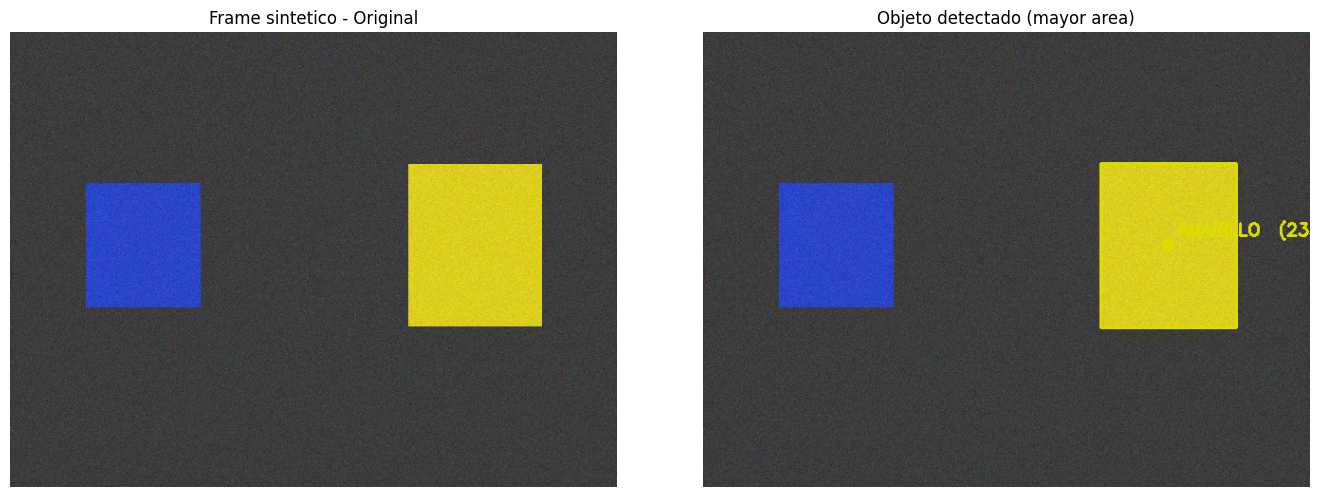


=== Resultado ===
  Se detectó cubo color AMARILLO
  Pixel    : (490, 225)
  Robot    : (235.0, 7.5) mm
  Area     : 24380 px2


In [14]:
def generar_frame_prueba(azul=True, amarillo=True, verde=False, rojo=False):
    """Crea un frame BGR sintetico para probar la pipeline sin camara."""
    frame = np.ones((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.uint8) * 60
    cubos = []
    if azul:     cubos.append(([115, 200, 200], ( 80, 160, 200, 290)))
    if amarillo: cubos.append(([ 28, 220, 220], (420, 140, 560, 310)))
    if verde:    cubos.append(([ 60, 200, 200], (250, 300, 380, 430)))
    if rojo:     cubos.append(([  5, 200, 200], (480, 300, 600, 420)))
    for (h, s, v), (x1, y1, x2, y2) in cubos:
        hsv_px = np.zeros((1,1,3), dtype=np.uint8)
        hsv_px[0,0] = [h, s, v]
        bgr = cv2.cvtColor(hsv_px, cv2.COLOR_HSV2BGR)[0,0].tolist()
        cv2.rectangle(frame, (x1,y1), (x2,y2), bgr, -1)
    noise = (np.random.randn(*frame.shape) * 255 * 0.04).astype(np.int16)
    return np.clip(frame.astype(np.int16) + noise, 0, 255).astype(np.uint8)


frame_orig = generar_frame_prueba(azul=True, amarillo=True)
frame_anot = frame_orig.copy()
resultado  = detectar_color_automatico(frame_anot, debug=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB))
axes[0].set_title('Frame sintetico - Original')
axes[1].imshow(cv2.cvtColor(frame_anot, cv2.COLOR_BGR2RGB))
axes[1].set_title('Objeto detectado (mayor area)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print('\n=== Resultado ===')
if resultado:
    print(f'  Se detectó cubo color {resultado["color"].upper()}')
    print(f'  Pixel    : ({resultado["cx_px"]:.0f}, {resultado["cy_px"]:.0f})')
    print(f'  Robot    : ({resultado["x_mm"]}, {resultado["y_mm"]}) mm')
    print(f'  Area     : {resultado["area"]} px2')
else:
    print('  NO DETECTADO — revisa rangos HSV')

Imagen cargada: foto.jfif


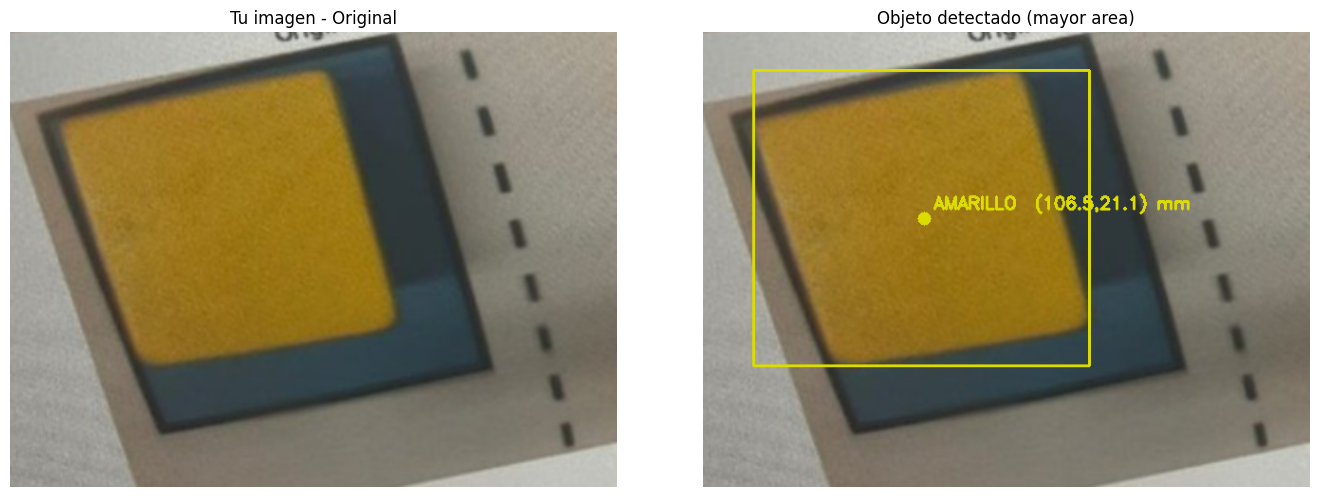


=== Resultado ===
  Se detectó cubo color AMARILLO
  Pixel    : (233, 198)
  Robot    : (106.5, 21.1) mm
  Area     : 79002 px2


In [13]:
def probar_con_imagen(ruta_imagen=None):
    if ruta_imagen is None:
        try:
            import tkinter as tk
            from tkinter import filedialog
            root = tk.Tk()
            root.withdraw()
            ruta_imagen = filedialog.askopenfilename(
                title='Selecciona la imagen del cubo',
                filetypes=[('Imagenes', '*.jpg *.jpeg *.png *.bmp *.jfif')]
            )
            root.destroy()
            if not ruta_imagen:
                print('No seleccionaste ninguna imagen.')
                return
        except Exception:
            print('No se pudo abrir dialogo. Pasa la ruta directamente:')
            print('  probar_con_imagen("mi_foto.jpg")')
            return

    frame = cv2.imread(ruta_imagen)
    if frame is None:
        print(f'No se pudo leer: {ruta_imagen}')
        return

    frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
    print(f'Imagen cargada: {ruta_imagen}')

    frame_orig = frame.copy()
    frame_anot = frame.copy()

    resultado = detectar_color_automatico(frame_anot, debug=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(cv2.cvtColor(frame_orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Tu imagen - Original')
    axes[1].imshow(cv2.cvtColor(frame_anot, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Objeto detectado (mayor area)')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()

    print('\n=== Resultado ===')
    if resultado:
        print(f'  Se detectó cubo color {resultado["color"].upper()}')
        print(f'  Pixel    : ({resultado["cx_px"]:.0f}, {resultado["cy_px"]:.0f})')
        print(f'  Robot    : ({resultado["x_mm"]}, {resultado["y_mm"]}) mm')
        print(f'  Area     : {resultado["area"]} px2')
    else:
        print('  No se detectó ningún cubo — revisa rangos HSV')


probar_con_imagen('foto.jfif')
# probar_con_imagen()

## 8. Demo en vivo con cámara real

Captura frames con el botón y muestra las detecciones activas.

> Presiona **Cerrar cámara** al terminar para liberar `/dev/video0`.

In [ ]:
def demo_en_vivo_jupyter(camera_index=0):
    import threading

    if ROBOT_DISPONIBLE:
        print('Moviendo a watch_pose...')
        mc.send_angles(WATCH_POSE, WATCH_SPEED)
        time.sleep(3)

    cap = abrir_camara(camera_index)
    if cap is None:
        return

    sel_modo = widgets.ToggleButtons(
        options=['todos', 'amarillo', 'azul', 'verde', 'rojo'],
        description='Modo:',
        style={'description_width': 'initial'}
    )
    btn_start = widgets.Button(description='Iniciar',       button_style='success')
    btn_stop  = widgets.Button(description='Pausar',        button_style='warning')
    btn_quit  = widgets.Button(description='Cerrar camara', button_style='danger')
    out       = widgets.Output()

    display(widgets.VBox([sel_modo, widgets.HBox([btn_start, btn_stop, btn_quit]), out]))

    corriendo = {'valor': False}  # flag compartido con el thread

    def loop():
        while corriendo['valor']:
            ret, frame = cap.read()
            if not ret or frame is None:
                time.sleep(0.1)
                continue

            frame_vis = frame.copy()
            modo = sel_modo.value

            if modo == 'todos':
                res_dict   = detect_all(frame_vis, debug=True)
                detectados = [r for r in res_dict.values() if r]
            else:
                res = detect_object(frame_vis, modo, debug=True)
                detectados = [res] if res else []

            cv2.putText(frame_vis, f'Modo: {modo.upper()}',
                        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
            y_off = 60
            if detectados:
                for r in detectados:
                    col  = HSV_RANGES[r['color']]['color_bgr']
                    info = (f"{r['color'].upper()}: "
                            f"px=({r['cx_px']:.0f},{r['cy_px']:.0f})  "
                            f"robot=({r['x_mm']},{r['y_mm']}) mm")
                    cv2.putText(frame_vis, info, (10, y_off),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
                    y_off += 28
            else:
                cv2.putText(frame_vis, 'No detectado', (10, y_off),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

            with out:
                clear_output(wait=True)
                fig, ax = plt.subplots(figsize=(10, 6))
                ax.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
                ax.axis('off')
                plt.tight_layout()
                plt.show()

            time.sleep(0.3)  # ~3 fps, sube a 0.1 si el Jetson aguanta

    def iniciar(_):
        if not corriendo['valor']:
            corriendo['valor'] = True
            t = threading.Thread(target=loop, daemon=True)
            t.start()

    def pausar(_):
        corriendo['valor'] = False

    def cerrar(_):
        corriendo['valor'] = False
        time.sleep(0.4)
        cap.release()
        gc.collect()
        with out:
            clear_output(wait=True)
            print('Camara cerrada.')

    btn_start.on_click(iniciar)
    btn_stop.on_click(pausar)
    btn_quit.on_click(cerrar)


demo_en_vivo_jupyter(camera_index=CAM_INDEX)

In [ ]:
def demo_en_vivo_jupyter(camera_index=0):
    if ROBOT_DISPONIBLE:
        print('Moviendo a watch_pose...')
        mc.send_angles(WATCH_POSE, WATCH_SPEED)
        time.sleep(3)

    cap = abrir_camara(camera_index)
    if cap is None:
        return

    sel_modo = widgets.ToggleButtons(
        options=['todos', 'amarillo', 'azul', 'verde', 'rojo'],
        description='Modo:',
        style={'description_width': 'initial'}
    )
    btn_cap  = widgets.Button(description='Capturar frame', button_style='primary')
    btn_quit = widgets.Button(description='Cerrar camara',  button_style='danger')
    out      = widgets.Output()

    display(widgets.VBox([sel_modo, widgets.HBox([btn_cap, btn_quit]), out]))

    def capturar(_):
        for _ in range(5):
            cap.read()
        ret, frame = cap.read()
        if not ret or frame is None:
            with out:
                clear_output(wait=True)
                print('Error al leer frame.')
            return

        frame_vis = frame.copy()
        modo = sel_modo.value

        if modo == 'todos':
            res_dict  = detect_all(frame_vis, debug=True)
            detectados = [r for r in res_dict.values() if r]
        else:
            res = detect_object(frame_vis, modo, debug=True)
            detectados = [res] if res else []

        cv2.putText(frame_vis, f'Modo: {modo.upper()}',
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)
        y_off = 60
        if detectados:
            for r in detectados:
                col  = HSV_RANGES[r['color']]['color_bgr']
                info = (f"{r['color'].upper()}: "
                        f"px=({r['cx_px']:.0f},{r['cy_px']:.0f})  "
                        f"robot=({r['x_mm']},{r['y_mm']}) mm")
                cv2.putText(frame_vis, info, (10, y_off),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)
                y_off += 28
        else:
            cv2.putText(frame_vis, 'No detectado', (10, y_off),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
            ax.axis('off')
            plt.tight_layout(); plt.show()
        if detectados:
            print(f'Detectados: {[r["color"] for r in detectados]}')

    def cerrar(_):
        cap.release()
        gc.collect()
        with out:
            clear_output(wait=True)
            print('Camara cerrada.')

    btn_cap.on_click(capturar)
    btn_quit.on_click(cerrar)


demo_en_vivo_jupyter(camera_index=CAM_INDEX)

## 9. Validación en 3 posiciones (P6.4)

**Procedimiento para cada posición:**
1. Coloca el cubo en la posición.
2. Lee `mc.get_coords()` → anota `X_real`, `Y_real`.
3. Ejecuta la celda → detecta con la cámara.
4. La tabla se acumula automáticamente.

Repite 3 veces cambiando `posicion_real_mm`.

In [ ]:
# Acumula entre ejecuciones — no reiniciar entre posiciones
try:
    tabla_validacion
except NameError:
    tabla_validacion = []

# ── EDITAR ANTES DE CADA MEDICION ─────────────────────────────────────
posicion_real_mm = (150.0, 0.0)  # (x_real, y_real) medido con mc.get_coords() o regla
color_a_detectar = 'amarillo'    # color del cubo en esta posicion

# Captura y deteccion
cap = abrir_camara(CAM_INDEX)
if cap is not None:
    for _ in range(5):
        cap.read()
    ret, frame = cap.read()
    cap.release()
    gc.collect()

    if ret:
        frame_vis = frame.copy()
        det = detect_object(frame_vis, color_a_detectar, debug=True)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Posicion {len(tabla_validacion)+1} – {color_a_detectar.upper()}')
        ax.axis('off')
        plt.tight_layout(); plt.show()

        ex, ey = posicion_real_mm
        if det:
            err_x  = abs(det['x_mm'] - ex)
            err_y  = abs(det['y_mm'] - ey)
            estado = 'OK' if max(err_x, err_y) < 15 else 'FALLO'
            tabla_validacion.append((
                len(tabla_validacion)+1, color_a_detectar,
                ex, ey, det['x_mm'], det['y_mm'], err_x, err_y, estado
            ))
            print(f'Real : x={ex}, y={ey}')
            print(f'Det  : x={det["x_mm"]}, y={det["y_mm"]}')
            print(f'Error: DeltaX={err_x:.1f} mm  DeltaY={err_y:.1f} mm  [{estado}]')
        else:
            print('Sin deteccion. Revisa HSV o iluminacion.')
    else:
        print('Error al capturar frame.')

# Tabla acumulada
if tabla_validacion:
    print(f'\n{"Pos":>3} {"Color":>10} {"X_real":>8} {"Y_real":>8} '
          f'{"X_det":>8} {"Y_det":>8} {"DX":>7} {"DY":>7} {"Estado":>8}')
    print('-'*75)
    for row in tabla_validacion:
        i, col, xr, yr, xd, yd, ex, ey, est = row
        print(f'{i:>3} {col:>10} {xr:>8.1f} {yr:>8.1f} '
              f'{xd:>8.1f} {yd:>8.1f} {ex:>7.1f} {ey:>7.1f} {est:>8}')
    errores_x = [r[6] for r in tabla_validacion]
    errores_y = [r[7] for r in tabla_validacion]
    print(f'Error medio: DX={np.mean(errores_x):.1f} mm  DY={np.mean(errores_y):.1f} mm  (objetivo < 15 mm)')

## 10. Función `get_object_position()` — para `main.py`

```python
from P6_deteccion_objetos import get_object_position

pos = get_object_position()  # retorna (x_mm, y_mm) o None
if pos:
    x_mm, y_mm = pos
```

In [ ]:
def get_object_position(target_color='amarillo', cam_index=CAM_INDEX, retries=5):
    """
    Abre la camara, intenta detectar el cubo hasta 'retries' veces,
    cierra la camara y retorna el resultado.
    Retorna (x_mm, y_mm) o None.
    """
    cap = abrir_camara(cam_index)
    if cap is None:
        print('[VISION] ERROR: no se pudo abrir camara.')
        return None

    result = None
    for _ in range(retries):
        ret, frame = cap.read()
        if not ret:
            time.sleep(0.1)
            continue
        result = detect_object(frame, target_color)
        if result is not None:
            break
        time.sleep(0.1)

    cap.release()
    gc.collect()

    if result is None:
        print('[VISION] Objeto NO detectado.')
    else:
        print(f'[VISION] Detectado -> x={result["x_mm"]} mm, y={result["y_mm"]} mm')

    return (result['x_mm'], result['y_mm']) if result else None


# Test rapido
pos = get_object_position()
print(f'Resultado: {pos}')

## 11. Resumen de entregables P6

| Punto | Estado | Descripción |
|-------|--------|-------------|
| P6.1 | ✓ | Rangos HSV calibrados (Sección 3 y 5) |
| P6.2 | ✓ | Detección de contorno y centroide `(cx, cy)` en píxeles (Sección 4c) |
| P6.3 | ✓ | Transformación `pixel_to_mm()` (Sección 4b) |
| P6.4 | ⏳ | Tabla validación 3 posiciones — completar en laboratorio (Sección 9) |
| P6.5 | ✓ | `detect_robust()`: ausencia, falsos positivos, iluminación (Sección 4d) |

**Pendiente en el laboratorio:**
1. Correr celda 0 siempre al abrir el notebook.
2. Calibrar HSV con la Sección 5 bajo la luz real del lab.
3. Medir `CAM_ORIGIN_X/Y_MM` y `SCALE_X/Y_MM_PX` con el robot conectado.
4. Completar la tabla de validación en la Sección 9.